# **FASE 3.2 – Agrupamento de Dados: Análises Diversas**

Nesta terceira etapa, daremos continuidade à análise avançando para a aplicação de métodos de agrupamento (clustering). O objetivo será identificar padrões e perfis entre os candidatos do ENEM a partir das variáveis selecionadas, considerando tanto aspectos socioeconômicos quanto de desempenho. Para isso, partiremos da base já limpa e padronizada, aplicaremos técnicas de normalização quando necessário e utilizaremos algoritmos de agrupamento, como o k-means, de forma a organizar os candidatos em grupos com características semelhantes. Em seguida, avaliaremos a qualidade desses agrupamentos por meio de métricas como o coeficiente de silhueta, permitindo interpretar os resultados e destacar perfis relevantes que auxiliem na compreensão do contexto educacional da região de abrangência do IFNMG.

Importando as bibliotecas que serão utilizadas.

In [1]:
import os
import re
import pandas as pd
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from matplotlib.ticker import FuncFormatter
from kmodes.kmodes import KModes

### **Realizando a leitura da base de área de MG**

In [2]:
df_final = pd.read_parquet(r"C:\Users\fernanda.leal\Documents\FERNANDA\TCC\DESENVOLVIMENTO\BASES\processed\MG.parquet", engine="fastparquet")
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,M,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,F,0.0,3,1,2,2,1.0,São Francisco,...,A,A,A,B,B,A,D,A,A,B
2,2018,11,M,0.0,3,1,2,2,3.0,Boa Esperança,...,B,A,A,A,A,A,B,B,B,B
3,2018,12,F,0.0,3,1,2,2,3.0,Vespasiano,...,A,A,A,B,A,A,B,A,A,A
4,2018,2,M,0.0,3,1,2,2,1.0,Montalvânia,...,A,A,A,B,A,A,C,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,M,1.0,2,3,2,2,NaN,Rio Vermelho,...,A,A,A,A,A,A,C,A,A,B
517823,2023,2,F,1.0,1,1,2,2,1.0,Juiz de Fora,...,A,A,A,C,A,A,D,A,A,B
517824,2023,2,M,1.0,1,1,2,2,1.0,Pouso Alegre,...,A,A,B,B,A,B,E,A,D,B
517825,2023,2,F,1.0,3,1,2,2,1.0,Ipaba,...,B,A,A,B,A,A,D,A,B,B


### **Codificação das variáveis**
Nesse caso, será realizado a transformação da variável **TP_SEXO**, convertendo o valor 'M' para 0 e o valor 'F' para 1.

In [3]:
df_final["TP_SEXO"] = df_final["TP_SEXO"].map({"F": 1, "M": 0})
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,0,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,1,0.0,3,1,2,2,1.0,São Francisco,...,A,A,A,B,B,A,D,A,A,B
2,2018,11,0,0.0,3,1,2,2,3.0,Boa Esperança,...,B,A,A,A,A,A,B,B,B,B
3,2018,12,1,0.0,3,1,2,2,3.0,Vespasiano,...,A,A,A,B,A,A,B,A,A,A
4,2018,2,0,0.0,3,1,2,2,1.0,Montalvânia,...,A,A,A,B,A,A,C,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,2,3,2,2,NaN,Rio Vermelho,...,A,A,A,A,A,A,C,A,A,B
517823,2023,2,1,1.0,1,1,2,2,1.0,Juiz de Fora,...,A,A,A,C,A,A,D,A,A,B
517824,2023,2,0,1.0,1,1,2,2,1.0,Pouso Alegre,...,A,A,B,B,A,B,E,A,D,B
517825,2023,2,1,1.0,3,1,2,2,1.0,Ipaba,...,B,A,A,B,A,A,D,A,B,B


Nesse caso, a variável **TP_ESTADO_CIVIL** foi recodificada para valores numéricos, de forma que Solteiro(a) foi representado por 0, Casado(a)/Companheiro(a) por 1, e as demais categorias (Divorciado(a), Desquitado(a), Separado(a) e Viúvo(a)) foram agrupadas sob o valor 2, representando o grupo “Outros”

In [4]:
df_final["TP_ESTADO_CIVIL"] = df_final["TP_ESTADO_CIVIL"].replace({
    "Solteiro(a)": 0,
    "Casado(a)/Companheiro(a)": 1,
    "Divorciado(a)/Separado(a)": 2,
    "Desquitado(a)": 2,
    "Viúvo(a)": 2
})
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,0,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,1,0.0,3,1,2,2,1.0,São Francisco,...,A,A,A,B,B,A,D,A,A,B
2,2018,11,0,0.0,3,1,2,2,3.0,Boa Esperança,...,B,A,A,A,A,A,B,B,B,B
3,2018,12,1,0.0,3,1,2,2,3.0,Vespasiano,...,A,A,A,B,A,A,B,A,A,A
4,2018,2,0,0.0,3,1,2,2,1.0,Montalvânia,...,A,A,A,B,A,A,C,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,2,3,2,2,NaN,Rio Vermelho,...,A,A,A,A,A,A,C,A,A,B
517823,2023,2,1,1.0,1,1,2,2,1.0,Juiz de Fora,...,A,A,A,C,A,A,D,A,A,B
517824,2023,2,0,1.0,1,1,2,2,1.0,Pouso Alegre,...,A,A,B,B,A,B,E,A,D,B
517825,2023,2,1,1.0,3,1,2,2,1.0,Ipaba,...,B,A,A,B,A,A,D,A,B,B


Nesse caso, aplicou-se o método one-hot encoding à variável **TP_COR_RACA**, criando colunas binárias (0 e 1) para cada categoria de cor/raça. Essa transformação permite representar variáveis categóricas de forma numérica, sem atribuir uma ordem entre as categorias.

In [5]:
df_final = pd.get_dummies(df_final, columns=["TP_COR_RACA"], prefix="COR_RACA")
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,1,2,2,1.0,Rio Pardo de Minas,MG,...,D,A,A,A,True,False,False,False,False,False
1,2018,2,1,0.0,1,2,2,1.0,São Francisco,MG,...,D,A,A,B,False,False,False,True,False,False
2,2018,11,0,0.0,1,2,2,3.0,Boa Esperança,MG,...,B,B,B,B,False,False,False,True,False,False
3,2018,12,1,0.0,1,2,2,3.0,Vespasiano,MG,...,B,A,A,A,False,False,False,True,False,False
4,2018,2,0,0.0,1,2,2,1.0,Montalvânia,MG,...,C,A,B,B,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,3,2,2,NaN,Rio Vermelho,MG,...,C,A,A,B,False,False,True,False,False,False
517823,2023,2,1,1.0,1,2,2,1.0,Juiz de Fora,MG,...,D,A,A,B,False,True,False,False,False,False
517824,2023,2,0,1.0,1,2,2,1.0,Pouso Alegre,MG,...,E,A,D,B,False,True,False,False,False,False
517825,2023,2,1,1.0,1,2,2,1.0,Ipaba,MG,...,D,A,B,B,False,False,False,True,False,False


Nesta etapa, será realizada a recodificação da variável **TP_NACIONALIDADE**, transformando as categorias originais em valores numéricos binários:

0 → Brasileiro(a), Brasileiro(a) Naturalizado(a) ou Brasileiro(a) Nato(a), nascido(a) no exterior

1 → Estrangeiro(a)

As observações com valor 0 (Não informado) serão removidas do conjunto de dados.

In [6]:
antes = len(df_final)
print(f"Total de linhas antes da exclusão: {antes}")

df_final = df_final[df_final["TP_NACIONALIDADE"] != 0].copy()

df_final.loc[:, "TP_NACIONALIDADE"] = df_final["TP_NACIONALIDADE"].replace({
    1: 0,  # Brasileiro(a)
    2: 0,  # Brasileiro(a) Naturalizado(a)
    4: 0,  # Brasileiro(a) Nato(a), nascido(a) no exterior
    3: 1   # Estrangeiro(a)
})

depois = len(df_final)
print(f"Total de linhas após a exclusão: {depois}")
print(f"Foram removidas {antes - depois} linhas (Não informadas).")
df_final

Total de linhas antes da exclusão: 517827
Total de linhas após a exclusão: 517522
Foram removidas 305 linhas (Não informadas).


,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,0,2,2,1.0,Rio Pardo de Minas,MG,...,D,A,A,A,True,False,False,False,False,False
1,2018,2,1,0.0,0,2,2,1.0,São Francisco,MG,...,D,A,A,B,False,False,False,True,False,False
2,2018,11,0,0.0,0,2,2,3.0,Boa Esperança,MG,...,B,B,B,B,False,False,False,True,False,False
3,2018,12,1,0.0,0,2,2,3.0,Vespasiano,MG,...,B,A,A,A,False,False,False,True,False,False
4,2018,2,0,0.0,0,2,2,1.0,Montalvânia,MG,...,C,A,B,B,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,1,2,2,NaN,Rio Vermelho,MG,...,C,A,A,B,False,False,True,False,False,False
517823,2023,2,1,1.0,0,2,2,1.0,Juiz de Fora,MG,...,D,A,A,B,False,True,False,False,False,False
517824,2023,2,0,1.0,0,2,2,1.0,Pouso Alegre,MG,...,E,A,D,B,False,True,False,False,False,False
517825,2023,2,1,1.0,0,2,2,1.0,Ipaba,MG,...,D,A,B,B,False,False,False,True,False,False


Após a limpeza e recodificação da variável **TP_NACIONALIDADE**, o conjunto de dados passou de 517827 para 517522 registros, resultando na exclusão de 305 observações com nacionalidade “Não informada”.

Nesta etapa, será realizada a recodificação da variável **TP_ENSINO**, transformando as categorias originais em valores numéricos binários:

0 → Educação Especial – Modalidade Substitutiva e Educação de Jovens e Adultos

1 → Ensino Regular

As observações com valor 0 (Não informado) serão removidas do conjunto de dados.

In [7]:
df_final.loc[:, "TP_ENSINO"] = df_final["TP_ENSINO"].replace({
    2: 0,  # Educação Especial – Modalidade Substitutiva
    3: 0  # Educação de Jovens e Adultos
})
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,0,2,2,1.0,Rio Pardo de Minas,MG,...,D,A,A,A,True,False,False,False,False,False
1,2018,2,1,0.0,0,2,2,1.0,São Francisco,MG,...,D,A,A,B,False,False,False,True,False,False
2,2018,11,0,0.0,0,2,2,0.0,Boa Esperança,MG,...,B,B,B,B,False,False,False,True,False,False
3,2018,12,1,0.0,0,2,2,0.0,Vespasiano,MG,...,B,A,A,A,False,False,False,True,False,False
4,2018,2,0,0.0,0,2,2,1.0,Montalvânia,MG,...,C,A,B,B,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,1,2,2,NaN,Rio Vermelho,MG,...,C,A,A,B,False,False,True,False,False,False
517823,2023,2,1,1.0,0,2,2,1.0,Juiz de Fora,MG,...,D,A,A,B,False,True,False,False,False,False
517824,2023,2,0,1.0,0,2,2,1.0,Pouso Alegre,MG,...,E,A,D,B,False,True,False,False,False,False
517825,2023,2,1,1.0,0,2,2,1.0,Ipaba,MG,...,D,A,B,B,False,False,False,True,False,False


Nesta etapa, será realizada a recodificação da variável **TP_ESCOLA**, transformando as categorias originais em valores numéricos binários:

0 → Pública

1 → Exterior e Privada

As observações com valor 1 (Não respondeu) serão removidas do conjunto de dados.

In [8]:
antes = len(df_final)
print(f"Total de linhas antes da exclusão: {antes}")

df_final = df_final[df_final["TP_ESCOLA"] != 1].copy()

df_final.loc[:, "TP_ESCOLA"] = df_final["TP_ESCOLA"].replace({
    2: 0,  # Pública
    3: 1,  # Exterior
    4: 1   # Privada
})
depois = len(df_final)
print(f"Total de linhas após a exclusão: {depois}")
print(f"Foram removidas {antes - depois} linhas (Não informadas).")
df_final

Total de linhas antes da exclusão: 517522
Total de linhas após a exclusão: 511774
Foram removidas 5748 linhas (Não informadas).


,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,0,2,0,1.0,Rio Pardo de Minas,MG,...,D,A,A,A,True,False,False,False,False,False
1,2018,2,1,0.0,0,2,0,1.0,São Francisco,MG,...,D,A,A,B,False,False,False,True,False,False
2,2018,11,0,0.0,0,2,0,0.0,Boa Esperança,MG,...,B,B,B,B,False,False,False,True,False,False
3,2018,12,1,0.0,0,2,0,0.0,Vespasiano,MG,...,B,A,A,A,False,False,False,True,False,False
4,2018,2,0,0.0,0,2,0,1.0,Montalvânia,MG,...,C,A,B,B,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,1,2,0,NaN,Rio Vermelho,MG,...,C,A,A,B,False,False,True,False,False,False
517823,2023,2,1,1.0,0,2,0,1.0,Juiz de Fora,MG,...,D,A,A,B,False,True,False,False,False,False
517824,2023,2,0,1.0,0,2,0,1.0,Pouso Alegre,MG,...,E,A,D,B,False,True,False,False,False,False
517825,2023,2,1,1.0,0,2,0,1.0,Ipaba,MG,...,D,A,B,B,False,False,False,True,False,False


Após a limpeza e recodificação da variável **TP_ESCOLA**, o conjunto de dados passou de 517522 para 511774 registros, resultando na exclusão de 5748 observações com nacionalidade “Não respondeu”.

Nesta etapa, será realizada a recodificação da variável **ESQ_PAI, ESC_MAE, OCU_PAI, OCU_MAE, RENDA_MENSAL, EMP_DOMESTICO, BANHEIRO, QTD_QUARTOS, CARRO, MOTO, GELADEIRA, FREEZER, LAVA_ROUPA, SECA_ROUPA, MICROONDAS, LAVA_LOUCA, ASPIRADOR, TV, DVD, TV_ASSINATURA, CELULAR, TELEFONE_FIXO, COMPUTADOR, INTERNET**, transformando as categorias originais em valores numéricos binários

In [9]:
colunas_categoricas = [
    'ESQ_PAI', 'ESC_MAE', 'OCU_PAI', 'OCU_MAE', 'RENDA_MENSAL',
    'EMP_DOMESTICO', 'BANHEIRO', 'QTD_QUARTOS', 'CARRO', 'MOTO',
    'GELADEIRA', 'FREEZER', 'LAVA_ROUPA', 'SECA_ROUPA', 'MICROONDAS',
    'LAVA_LOUCA', 'ASPIRADOR', 'TV', 'DVD', 'TV_ASSINATURA',
    'CELULAR', 'TELEFONE_FIXO', 'COMPUTADOR', 'INTERNET'
]
mapa = {chr(i + 65): i for i in range(26)}  # 'A'->0, 'B'->1, ..., 'Z'->25

for col in colunas_categoricas:
    df_final[col] = df_final[col].map(mapa)

df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,0,2,0,1.0,Rio Pardo de Minas,MG,...,3.0,0.0,0.0,0.0,True,False,False,False,False,False
1,2018,2,1,0.0,0,2,0,1.0,São Francisco,MG,...,3.0,0.0,0.0,1.0,False,False,False,True,False,False
2,2018,11,0,0.0,0,2,0,0.0,Boa Esperança,MG,...,1.0,1.0,1.0,1.0,False,False,False,True,False,False
3,2018,12,1,0.0,0,2,0,0.0,Vespasiano,MG,...,1.0,0.0,0.0,0.0,False,False,False,True,False,False
4,2018,2,0,0.0,0,2,0,1.0,Montalvânia,MG,...,2.0,0.0,1.0,1.0,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,1,2,0,NaN,Rio Vermelho,MG,...,2.0,0.0,0.0,1.0,False,False,True,False,False,False
517823,2023,2,1,1.0,0,2,0,1.0,Juiz de Fora,MG,...,3.0,0.0,0.0,1.0,False,True,False,False,False,False
517824,2023,2,0,1.0,0,2,0,1.0,Pouso Alegre,MG,...,4.0,0.0,3.0,1.0,False,True,False,False,False,False
517825,2023,2,1,1.0,0,2,0,1.0,Ipaba,MG,...,3.0,0.0,1.0,1.0,False,False,False,True,False,False


### **Filtrando a área de abrangencia do IFNMG**

In [10]:
cidades_filtro = [
    "Almenara","Alvorada de Minas","Angelândia","Araçuaí","Aricanduva","Arinos","Ataléia",
    "Augusto de Lima","Bandeira","Berilo","Berizal","Bertópolis","Bocaiúva","Bonfinópolis de Minas",
    "Bonito de Minas","Botumirim","Brasília de Minas","Buenópolis","Buritis","Buritizeiro","Cabeceira Grande",
    "Cachoeira de Pajeú","Campanário","Campo Azul","Capelinha","Capitão Enéas","Caraí","Carbonita",
    "Carlos Chagas","Catuji","Catuti","Chapada Gaúcha","Chapada do Norte","Claro dos Poções","Comercinho",
    "Coração de Jesus","Corinto","Coronel Murta","Couto de Magalhães de Minas","Cristália","Crisólita",
    "Curral de Dentro","Curvelo","Cônego Marinho","Datas","Diamantina","Divisa Alegre","Divisópolis",
    "Dom Bosco","Engenheiro Navarro","Espinosa","Felisburgo","Felixlândia","Felício dos Santos","Formoso",
    "Francisco Badaró","Francisco Dumont","Francisco Sá","Franciscópolis","Frei Gaspar","Fronteira dos Vales",
    "Fruta de Leite","Gameleiras","Glaucilândia","Gouveia","Grão Mogol","Guaraciama","Ibiaí","Ibiracatu",
    "Icaraí de Minas","Indaiabira","Inimutaba","Itacambira","Itacarambi","Itaipé","Itamarandiba","Itambacuri",
    "Itaobim","Itinga","Jacinto","Janaúba","Januária","Japonvar","Jaíba","Jenipapo de Minas","Jequitaí",
    "Jequitinhonha","Joaquim Felício","Joaíma","Jordânia","Josenópolis","José Gonçalves de Minas","Juramento",
    "Juvenília","Ladainha","Lagoa dos Patos","Lassance","Leme do Prado","Lontra","Luislândia","Machacalis",
    "Malacacheta","Mamonas","Manga","Mata Verde","Matias Cardoso","Mato Verde","Medina","Minas Novas",
    "Mirabela","Miravânia","Monjolos","Montalvânia","Monte Azul","Monte Formoso","Montes Claros","Montezuma",
    "Morro da Garça","Nanuque","Natalândia","Ninheira","Nova Módica","Nova Porteirinha","Novo Cruzeiro",
    "Novo Oriente de Minas","Novorizonte","Olhos-d'Água","Ouro Verde de Minas","Padre Carvalho","Padre Paraíso",
    "Pai Pedro","Palmópolis","Patis","Pavão","Pedra Azul","Pedras de Maria da Cruz","Pescador","Pintópolis",
    "Pirapora","Ponto Chique","Ponto dos Volantes","Porteirinha","Poté","Presidente Juscelino",
    "Presidente Kubitschek","Riachinho","Riacho dos Machados","Rio Pardo de Minas","Rio do Prado","Rubelita",
    "Rubim","Salinas","Salto da Divisa","Santa Cruz de Salinas","Santa Fé de Minas","Santa Helena de Minas",
    "Santa Maria do Salto","Santo Antônio do Itambé","Santo Antônio do Jacinto","Santo Antônio do Retiro",
    "Santo Hipólito","Senador Modestino Gonçalves","Serra Azul de Minas","Serra dos Aimorés","Serranópolis de Minas",
    "Serro","Setubinha","São Francisco","São Gonçalo do Rio Preto","São José do Divino","São João da Lagoa",
    "São João da Ponte","São João das Missões","São João do Pacuí","São João do Paraíso","São Romão","Taiobeiras",
    "Teófilo Otoni","Três Marias","Turmalina","Ubaí","Umburatiba","Unaí","Uruana de Minas","Urucuia",
    "Vargem Grande do Rio Pardo","Varzelândia","Verdelândia","Veredinha","Virgem da Lapa","Várzea da Palma",
    "Água Boa","Águas Formosas","Águas Vermelhas"
]
df_ifnmg = df_final[(df_final['NO_MUNICIPIO_ESC'].isin(cidades_filtro))]
df_ifnmg

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,0,2,0,1.0,Rio Pardo de Minas,MG,...,3.0,0.0,0.0,0.0,True,False,False,False,False,False
1,2018,2,1,0.0,0,2,0,1.0,São Francisco,MG,...,3.0,0.0,0.0,1.0,False,False,False,True,False,False
4,2018,2,0,0.0,0,2,0,1.0,Montalvânia,MG,...,2.0,0.0,1.0,1.0,False,False,False,True,False,False
6,2018,2,0,0.0,0,2,0,1.0,Chapada do Norte,MG,...,2.0,0.0,1.0,1.0,False,False,False,True,False,False
9,2018,3,1,0.0,0,2,0,1.0,Teófilo Otoni,MG,...,4.0,0.0,1.0,1.0,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517770,2023,3,1,1.0,0,2,0,1.0,Montes Claros,MG,...,4.0,0.0,2.0,1.0,False,False,False,True,False,False
517781,2023,3,1,1.0,0,2,0,1.0,Montes Claros,MG,...,1.0,0.0,0.0,1.0,False,False,False,True,False,False
517789,2023,4,0,1.0,0,2,0,NaN,Teófilo Otoni,MG,...,3.0,0.0,0.0,1.0,False,True,False,False,False,False
517799,2023,2,0,1.0,0,2,0,1.0,Montes Claros,MG,...,4.0,1.0,2.0,1.0,False,False,False,True,False,False


## **Agrupamento de Dados**

Nesta seção, são apresentados os principais resultados do Agrupamento de Dados aplicados à base do ENEM, com foco nos candidatos da área de abrangência do IFNMG. O objetivo das análises foi compreender o perfil socioeconômico dos participantes, considerando aspectos como escolaridade dos pais, renda familiar e acesso a bens e serviços.

## **K-modes de algumas variáveis [sexo, faixa etaria, tipo de escola e escolaridade e renda]**

Colunas encontradas no df_ifnmg: ['TP_SEXO', 'TP_FAIXA_ETARIA', 'TP_ESCOLA', 'TP_ENSINO', 'RENDA_MENSAL']

Formato da base para KModes: (69594, 5)
Primeiras linhas:
   TP_SEXO  TP_FAIXA_ETARIA  TP_ESCOLA  TP_ENSINO  RENDA_MENSAL
0        0                3          0        1.0           1.0
1        1                2          0        1.0           3.0
4        0                2          0        1.0           2.0
6        0                2          0        1.0           0.0
9        1                3          0        1.0           7.0
k=2 → custo=88422 | silhouette=0.3357
k=3 → custo=71254 | silhouette=0.3091
k=4 → custo=61031 | silhouette=0.3663
k=5 → custo=55424 | silhouette=0.2603
k=6 → custo=55634 | silhouette=0.3349
k=7 → custo=50389 | silhouette=0.2100
k=8 → custo=46891 | silhouette=0.2800
k=9 → custo=45380 | silhouette=0.3061


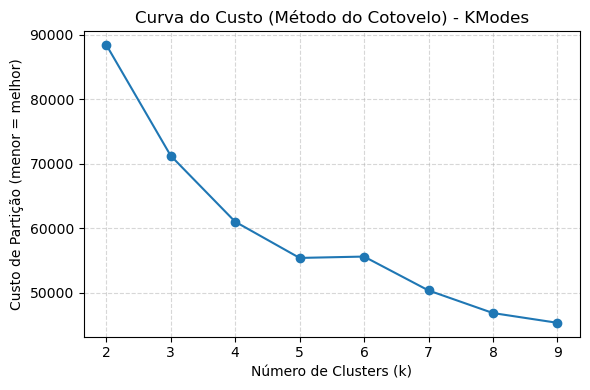

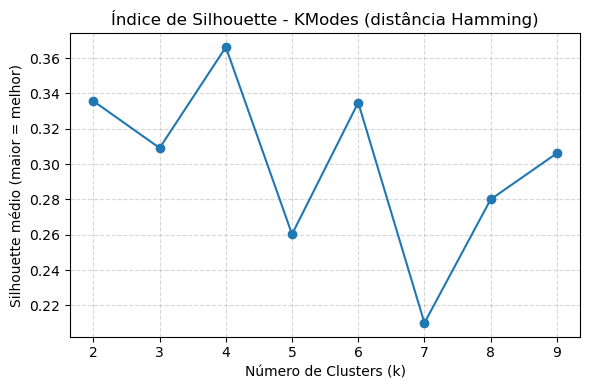


➡ Melhor k pelo menor custo: 9
➡ Melhor k pelo maior silhouette: 4

Quantidade de observações por cluster (k=5):
Cluster_KModes
0    20441
1    16006
2     9011
3     9939
4    14197
Name: count, dtype: int64

Modos (centroides) de cada cluster:
  TP_SEXO TP_FAIXA_ETARIA TP_ESCOLA TP_ENSINO RENDA_MENSAL  Cluster_KModes
0       1               3         0       1.0          2.0               0
1       0               3         0       1.0          1.0               1
2       0               2         0       1.0          2.0               2
3       1               3         0       1.0          1.0               3
4       1               2         0       1.0          1.0               4

% de sexo dentro de cada cluster:
TP_SEXO             0      1
Cluster_KModes              
0                13.8   86.2
1               100.0    0.0
2               100.0    0.0
3                 0.0  100.0
4                 0.0  100.0

% de tipo de escola dentro de cada cluster:
TP_ESCOLA          0

In [13]:
colunas_desejadas = ["TP_SEXO", "TP_FAIXA_ETARIA", "TP_ESCOLA", "TP_ENSINO", "RENDA_MENSAL"]

presentes = [c for c in colunas_desejadas if c in df_ifnmg.columns]
faltando = [c for c in colunas_desejadas if c not in df_ifnmg.columns]

print("Colunas encontradas no df_ifnmg:", presentes)
if faltando:
    print("⚠️ Atenção, essas colunas NÃO foram encontradas no df_ifnmg:", faltando)

# Base categórica sem NA
base_cat = df_ifnmg[presentes].dropna().copy()

print("\nFormato da base para KModes:", base_cat.shape)
print("Primeiras linhas:")
print(base_cat.head())

# Para o KModes: transformar em string (categórico)
X_kmodes = base_cat.astype(str).to_numpy()

# Para o silhouette: codificar as categorias como inteiros
base_cat_codes = base_cat.copy()
for c in base_cat_codes.columns:
    base_cat_codes[c] = base_cat_codes[c].astype("category").cat.codes
X_sil = base_cat_codes.to_numpy()

custos = []
silhuetas = []
Ks = range(2, 10)

for k in Ks:
    km = KModes(n_clusters=k, init="Huang", n_init=10, random_state=42)
    labels = km.fit_predict(X_kmodes)

    custo = km.cost_
    custos.append(custo)

    sil = silhouette_score(X_sil, labels, metric="hamming")
    silhuetas.append(sil)

    print(f"k={k} → custo={custo:.0f} | silhouette={sil:.4f}")

# Plot do custo
plt.figure(figsize=(6, 4))
plt.plot(Ks, custos, marker="o")
plt.title("Curva do Custo (Método do Cotovelo) - KModes")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Custo de Partição (menor = melhor)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Plot do silhouette
plt.figure(figsize=(6, 4))
plt.plot(Ks, silhuetas, marker="o")
plt.title("Índice de Silhouette - KModes (distância Hamming)")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Silhouette médio (maior = melhor)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Melhor k por custo e por silhouette (apenas para você olhar, não para seguir cegamente)
melhor_k_custo = Ks[np.argmin(custos)]
melhor_k_sil = Ks[np.argmax(silhuetas)]

print(f"\n➡ Melhor k pelo menor custo: {melhor_k_custo}")
print(f"➡ Melhor k pelo maior silhouette: {melhor_k_sil}")

# Escolha manual do k (por ex.: 4 ou 5, depois de olhar os gráficos)
k_escolhido = 5   # <<< TROQUE AQUI QUANDO DEFINIR

kmodes_final = KModes(n_clusters=k_escolhido, init="Huang", n_init=10, random_state=42)
labels_final = kmodes_final.fit_predict(X_kmodes)

base_cat = base_cat.copy()
base_cat["Cluster_KModes"] = labels_final

print(f"\nQuantidade de observações por cluster (k={k_escolhido}):")
print(base_cat["Cluster_KModes"].value_counts().sort_index())

centroides = pd.DataFrame(kmodes_final.cluster_centroids_, columns=base_cat.columns[:-1])
centroides["Cluster_KModes"] = centroides.index
print("\nModos (centroides) de cada cluster:")
print(centroides)

df_ifnmg = df_ifnmg.copy()
df_ifnmg.loc[base_cat.index, "Cluster_KModes"] = base_cat["Cluster_KModes"].values

if "TP_SEXO" in presentes:
    print("\n% de sexo dentro de cada cluster:")
    print(
        (pd.crosstab(base_cat["Cluster_KModes"], base_cat["TP_SEXO"], normalize="index") * 100).round(1)
    )

if "TP_ESCOLA" in presentes:
    print("\n% de tipo de escola dentro de cada cluster:")
    print(
        (pd.crosstab(base_cat["Cluster_KModes"], base_cat["TP_ESCOLA"], normalize="index") * 100).round(1)
    )

print(f"\nA coluna 'Cluster_KModes' (k={k_escolhido}) foi adicionada ao df_ifnmg com sucesso!")
